# RUN The Cells Sequentially, one after the other ------------------>

TEST EDA

In [ ]:

# 1.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For reproducibility
np.random.seed(42)

# ================================
# 2. LOAD DATA

df = pd.read_csv("/content/BostonHousing.csv")

print("Original shape:", df.shape)
df.head()

Original shape: (506, 14)


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [ ]:
# 3. CREATE COPY (IMPORTANT)
# ================================
df_missing = df.copy()

# Identify target column
target_col = "medv"

# Feature columns only
feature_cols = df.columns.drop(target_col)

In [ ]:
# 4. ADD RANDOM MISSINGNESS (MCAR)
# ================================
# 3%–7% missing per column

missing_rates = {
    col: np.random.uniform(0.03, 0.05)
    for col in feature_cols
}

for col in feature_cols:
    mask = np.random.rand(len(df)) < missing_rates[col]
    df_missing.loc[mask, col] = np.nan

print("Random missingness added.")


Random missingness added.


In [ ]:
# 5. ADD DEPENDENCY-BASED MISSINGNESS (MAR)
# ================================

# Example 1: High LSTAT → more missing in RM
mask1 = df_missing["lstat"] > df_missing["lstat"].median()
rm_missing = (np.random.rand(len(df)) < 0.08) & mask1
df_missing.loc[rm_missing, "rm"] = np.nan

# Example 2: Older houses → TAX missing
mask2 = df_missing["age"] > df_missing["age"].median()
tax_missing = (np.random.rand(len(df)) < 0.06) & mask2
df_missing.loc[tax_missing, "tax"] = np.nan

print("Dependency-based missingness added.")

Dependency-based missingness added.


In [ ]:
# 6. SAVE NEW DATASET
# ================================
df_missing.to_csv("BostonHousing_missing.csv", index=False)

print("New dataset saved as BostonHousing_missing.csv")

New dataset saved as BostonHousing_missing.csv


In [ ]:
# 7. CHECK MISSING VALUES
# ================================

missing_percent = df_missing.isnull().mean() * 100
print("\nMissing percentage per column:\n")
print(missing_percent.sort_values(ascending=False))


Missing percentage per column:

rm         6.916996
tax        6.719368
indus      5.533597
dis        4.940711
zn         4.545455
crim       4.545455
lstat      4.347826
b          4.347826
rad        3.754941
chas       3.754941
age        3.359684
nox        3.162055
ptratio    2.371542
medv       0.000000
dtype: float64


In [ ]:
df_missing.head(100)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,NaN,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,NaN,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.12204,0.0,2.89,0.0,0.445,6.625,57.8,3.4952,2.0,276.0,18.0,357.98,6.65,28.4
96,0.11504,0.0,2.89,0.0,0.445,6.163,69.6,3.4952,2.0,276.0,18.0,NaN,11.34,21.4
97,0.12083,0.0,2.89,0.0,0.445,8.069,76.0,3.4952,2.0,276.0,18.0,396.90,4.21,38.7
98,0.08187,0.0,2.89,0.0,0.445,7.820,36.9,3.4952,2.0,276.0,18.0,393.53,3.57,43.8


In [ ]:
# ================================
# 4. DATA SPLITTING: Numerical vs Categorical
# ================================
print("\n" + "=" * 60)
print("DATA SPLITTING: NUMERICAL vs CATEGORICAL")
print("=" * 60)

numerical_data = df_missing.select_dtypes(include='number')
numerical_features = numerical_data.columns.tolist()

categorical_data = df_missing.select_dtypes(include='object')
categorical_features = categorical_data.columns.tolist()

print(f"\nNumerical features ({len(numerical_features)}): {numerical_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")


DATA SPLITTING: NUMERICAL vs CATEGORICAL

Numerical features (14): ['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'b', 'lstat', 'medv']
Categorical features (0): []


In [ ]:
# 5. DESCRIPTIVE STATISTICS
# ================================
print("\n" + "=" * 60)
print("DESCRIPTIVE STATISTICS")
print("=" * 60)

print("\n--- Summary Statistics (Numerical) ---")
print(numerical_data.describe().T.round(3))

print("\n--- Variance of Numerical Features ---")
print(numerical_data.var().round(3))


DESCRIPTIVE STATISTICS

--- Summary Statistics (Numerical) ---
         count     mean      std      min      25%      50%      75%      max
crim     483.0    3.692    8.761    0.006    0.083    0.259    3.695   88.976
zn       483.0   11.489   23.492    0.000    0.000    0.000   12.500  100.000
indus    478.0   11.075    6.818    0.460    5.145    9.690   18.100   27.740
chas     487.0    0.062    0.241    0.000    0.000    0.000    0.000    1.000
nox      490.0    0.554    0.116    0.385    0.449    0.538    0.624    0.871
rm       471.0    6.301    0.712    3.561    5.887    6.219    6.630    8.780
age      489.0   68.621   28.149    2.900   45.100   77.300   94.100  100.000
dis      481.0    3.820    2.089    1.130    2.107    3.272    5.215   12.126
rad      487.0    9.520    8.680    1.000    4.000    5.000   24.000   24.000
tax      472.0  407.394  168.130  187.000  279.750  330.000  666.000  711.000
ptratio  494.0   18.468    2.164   12.600   17.325   19.100   20.200   22.000


In [ ]:
# 6. SKEWNESS ANALYSIS
# ================================
print("\n" + "=" * 60)
print("SKEWNESS ANALYSIS")
print("=" * 60)

skewness = numerical_data.skew()
print("\nSkewness per feature:")
print(skewness.round(3))

def interpret_skew(s):
    if abs(s) < 0.5:
        return "Fairly symmetrical"
    elif abs(s) < 1.0:
        return "Moderately skewed"
    else:
        return "Highly skewed"

print("\nSkewness Interpretation:")
for col, s in skewness.items():
    direction = "Right" if s > 0 else "Left" if s < 0 else "None"
    print(f"  {col:<12}: {s:>7.3f}  → {direction}-skewed | {interpret_skew(s)}")


SKEWNESS ANALYSIS

Skewness per feature:
crim       5.151
zn         2.212
indus      0.275
chas       3.658
nox        0.751
rm         0.394
age       -0.600
dis        0.971
rad        1.016
tax        0.691
ptratio   -0.800
b         -2.862
lstat      0.886
medv       1.108
dtype: float64

Skewness Interpretation:
  crim        :   5.151  → Right-skewed | Highly skewed
  zn          :   2.212  → Right-skewed | Highly skewed
  indus       :   0.275  → Right-skewed | Fairly symmetrical
  chas        :   3.658  → Right-skewed | Highly skewed
  nox         :   0.751  → Right-skewed | Moderately skewed
  rm          :   0.394  → Right-skewed | Fairly symmetrical
  age         :  -0.600  → Left-skewed | Moderately skewed
  dis         :   0.971  → Right-skewed | Moderately skewed
  rad         :   1.016  → Right-skewed | Highly skewed
  tax         :   0.691  → Right-skewed | Moderately skewed
  ptratio     :  -0.800  → Left-skewed | Moderately skewed
  b           :  -2.862  → Left-ske


MISSING VALUES ANALYSIS

Missing values per column:
         Missing Count  Missing %
rm                  35       6.92
tax                 34       6.72
indus               28       5.53
dis                 25       4.94
zn                  23       4.55
crim                23       4.55
lstat               22       4.35
b                   22       4.35
rad                 19       3.75
chas                19       3.75
age                 17       3.36
nox                 16       3.16
ptratio             12       2.37


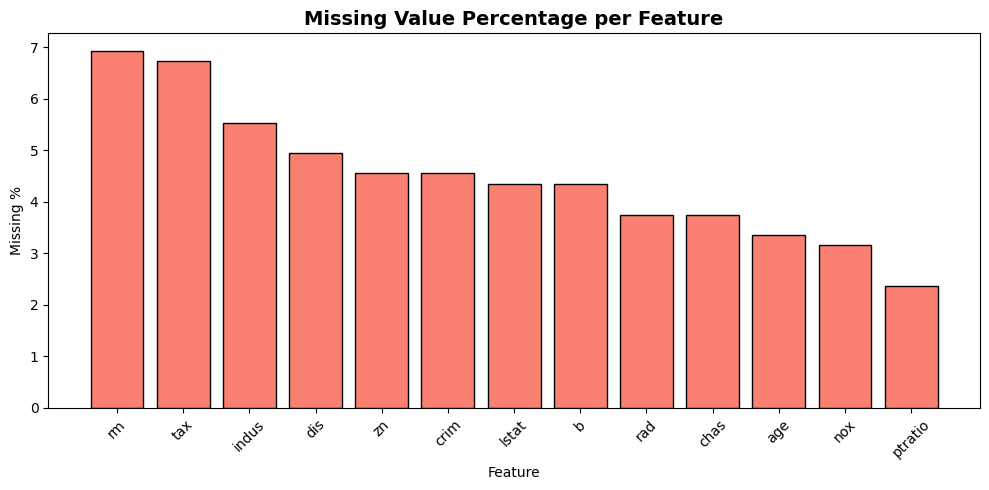

In [ ]:
# 7. MISSING VALUES ANALYSIS
# ================================
print("\n" + "=" * 60)
print("MISSING VALUES ANALYSIS")
print("=" * 60)

missing_count = df_missing.isnull().sum()
missing_pct = df_missing.isnull().mean() * 100
missing_df = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing %": missing_pct.round(2)
}).sort_values("Missing %", ascending=False)

print("\nMissing values per column:")
print(missing_df[missing_df["Missing Count"] > 0])

  # # Plot: Missing value heatmap
  # plt.figure(figsize=(12, 5))
  # sns.heatmap(df_missing.isnull(), cbar=False, cmap="viridis", yticklabels=False)
  # plt.title("Missing Values Heatmap", fontsize=14, fontweight='bold')
  # plt.tight_layout()
  # plt.savefig("missing_heatmap.png", dpi=150)
  # plt.show()

# Plot: Missing value bar chart
cols_with_missing = missing_df[missing_df["Missing Count"] > 0]
plt.figure(figsize=(10, 5))
plt.bar(cols_with_missing.index, cols_with_missing["Missing %"], color='salmon', edgecolor='black')
plt.title("Missing Value Percentage per Feature", fontsize=14, fontweight='bold')
plt.xlabel("Feature")
plt.ylabel("Missing %")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("missing_bar.png", dpi=150)
plt.show()


HISTOGRAMS & DISTRIBUTIONS


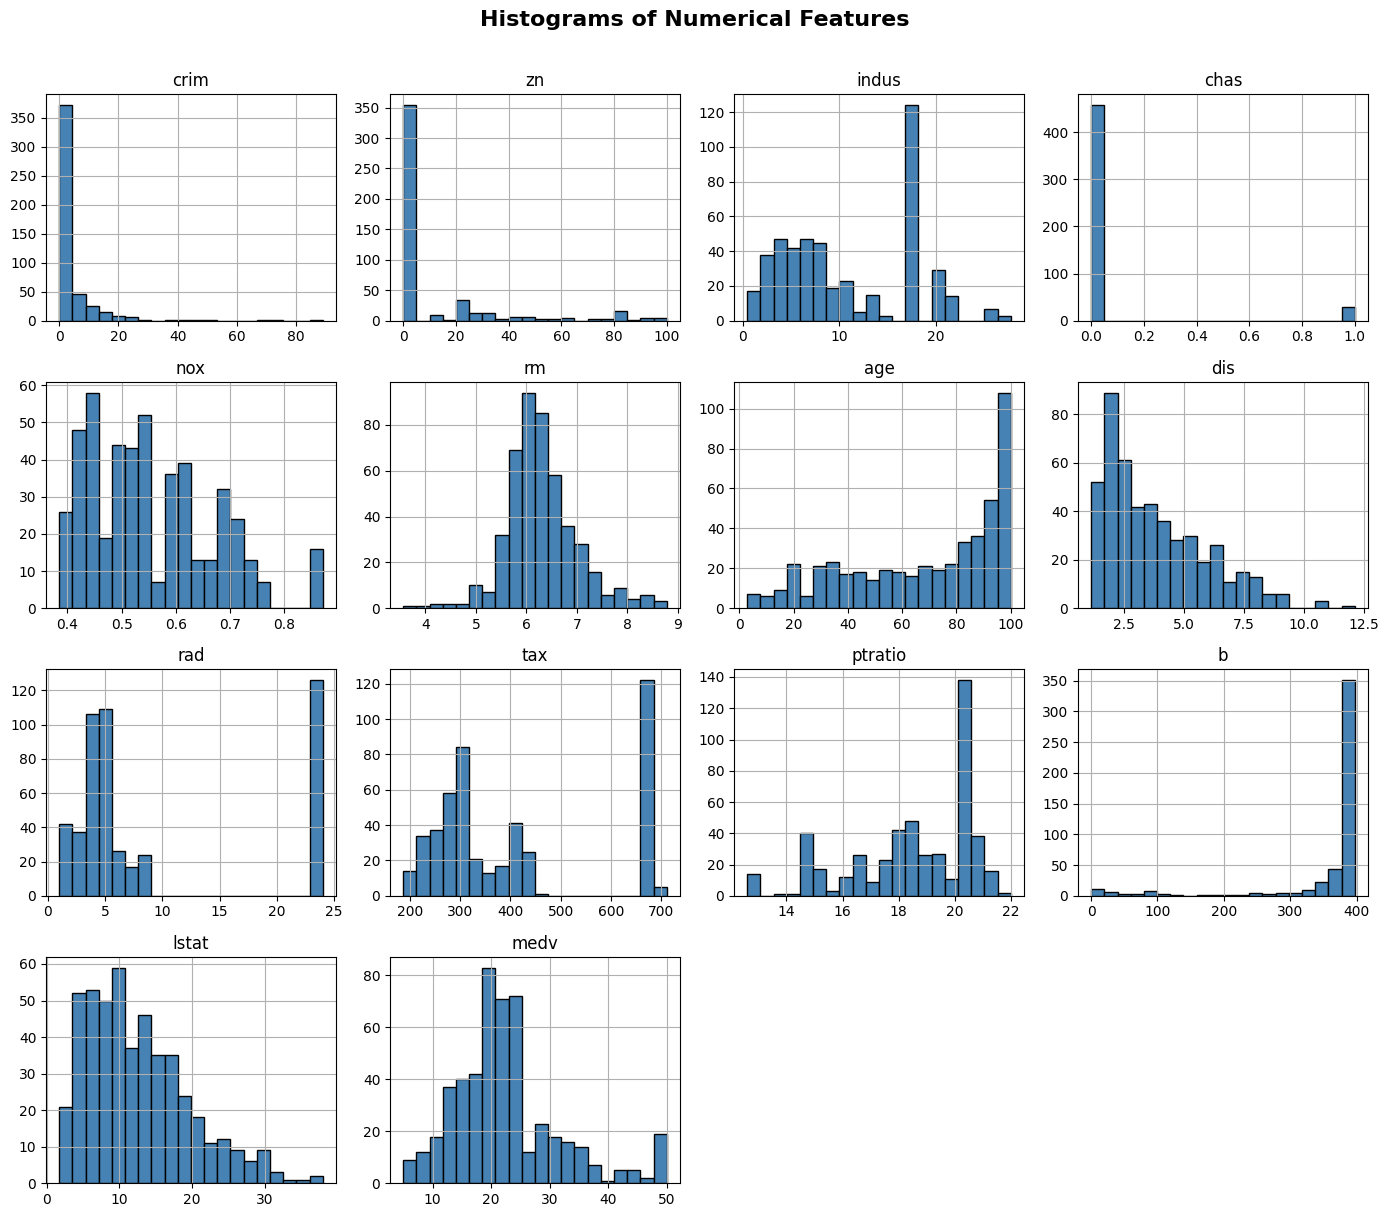

In [ ]:
# 8. HISTOGRAMS & DISTRIBUTIONS
# ================================
print("\n" + "=" * 60)
print("HISTOGRAMS & DISTRIBUTIONS")
print("=" * 60)

numerical_data.hist(figsize=(14, 12), bins=20, edgecolor='black', color='steelblue')
plt.suptitle("Histograms of Numerical Features", fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("histograms.png", dpi=150)
plt.show()


BOX PLOTS — OUTLIER DETECTION


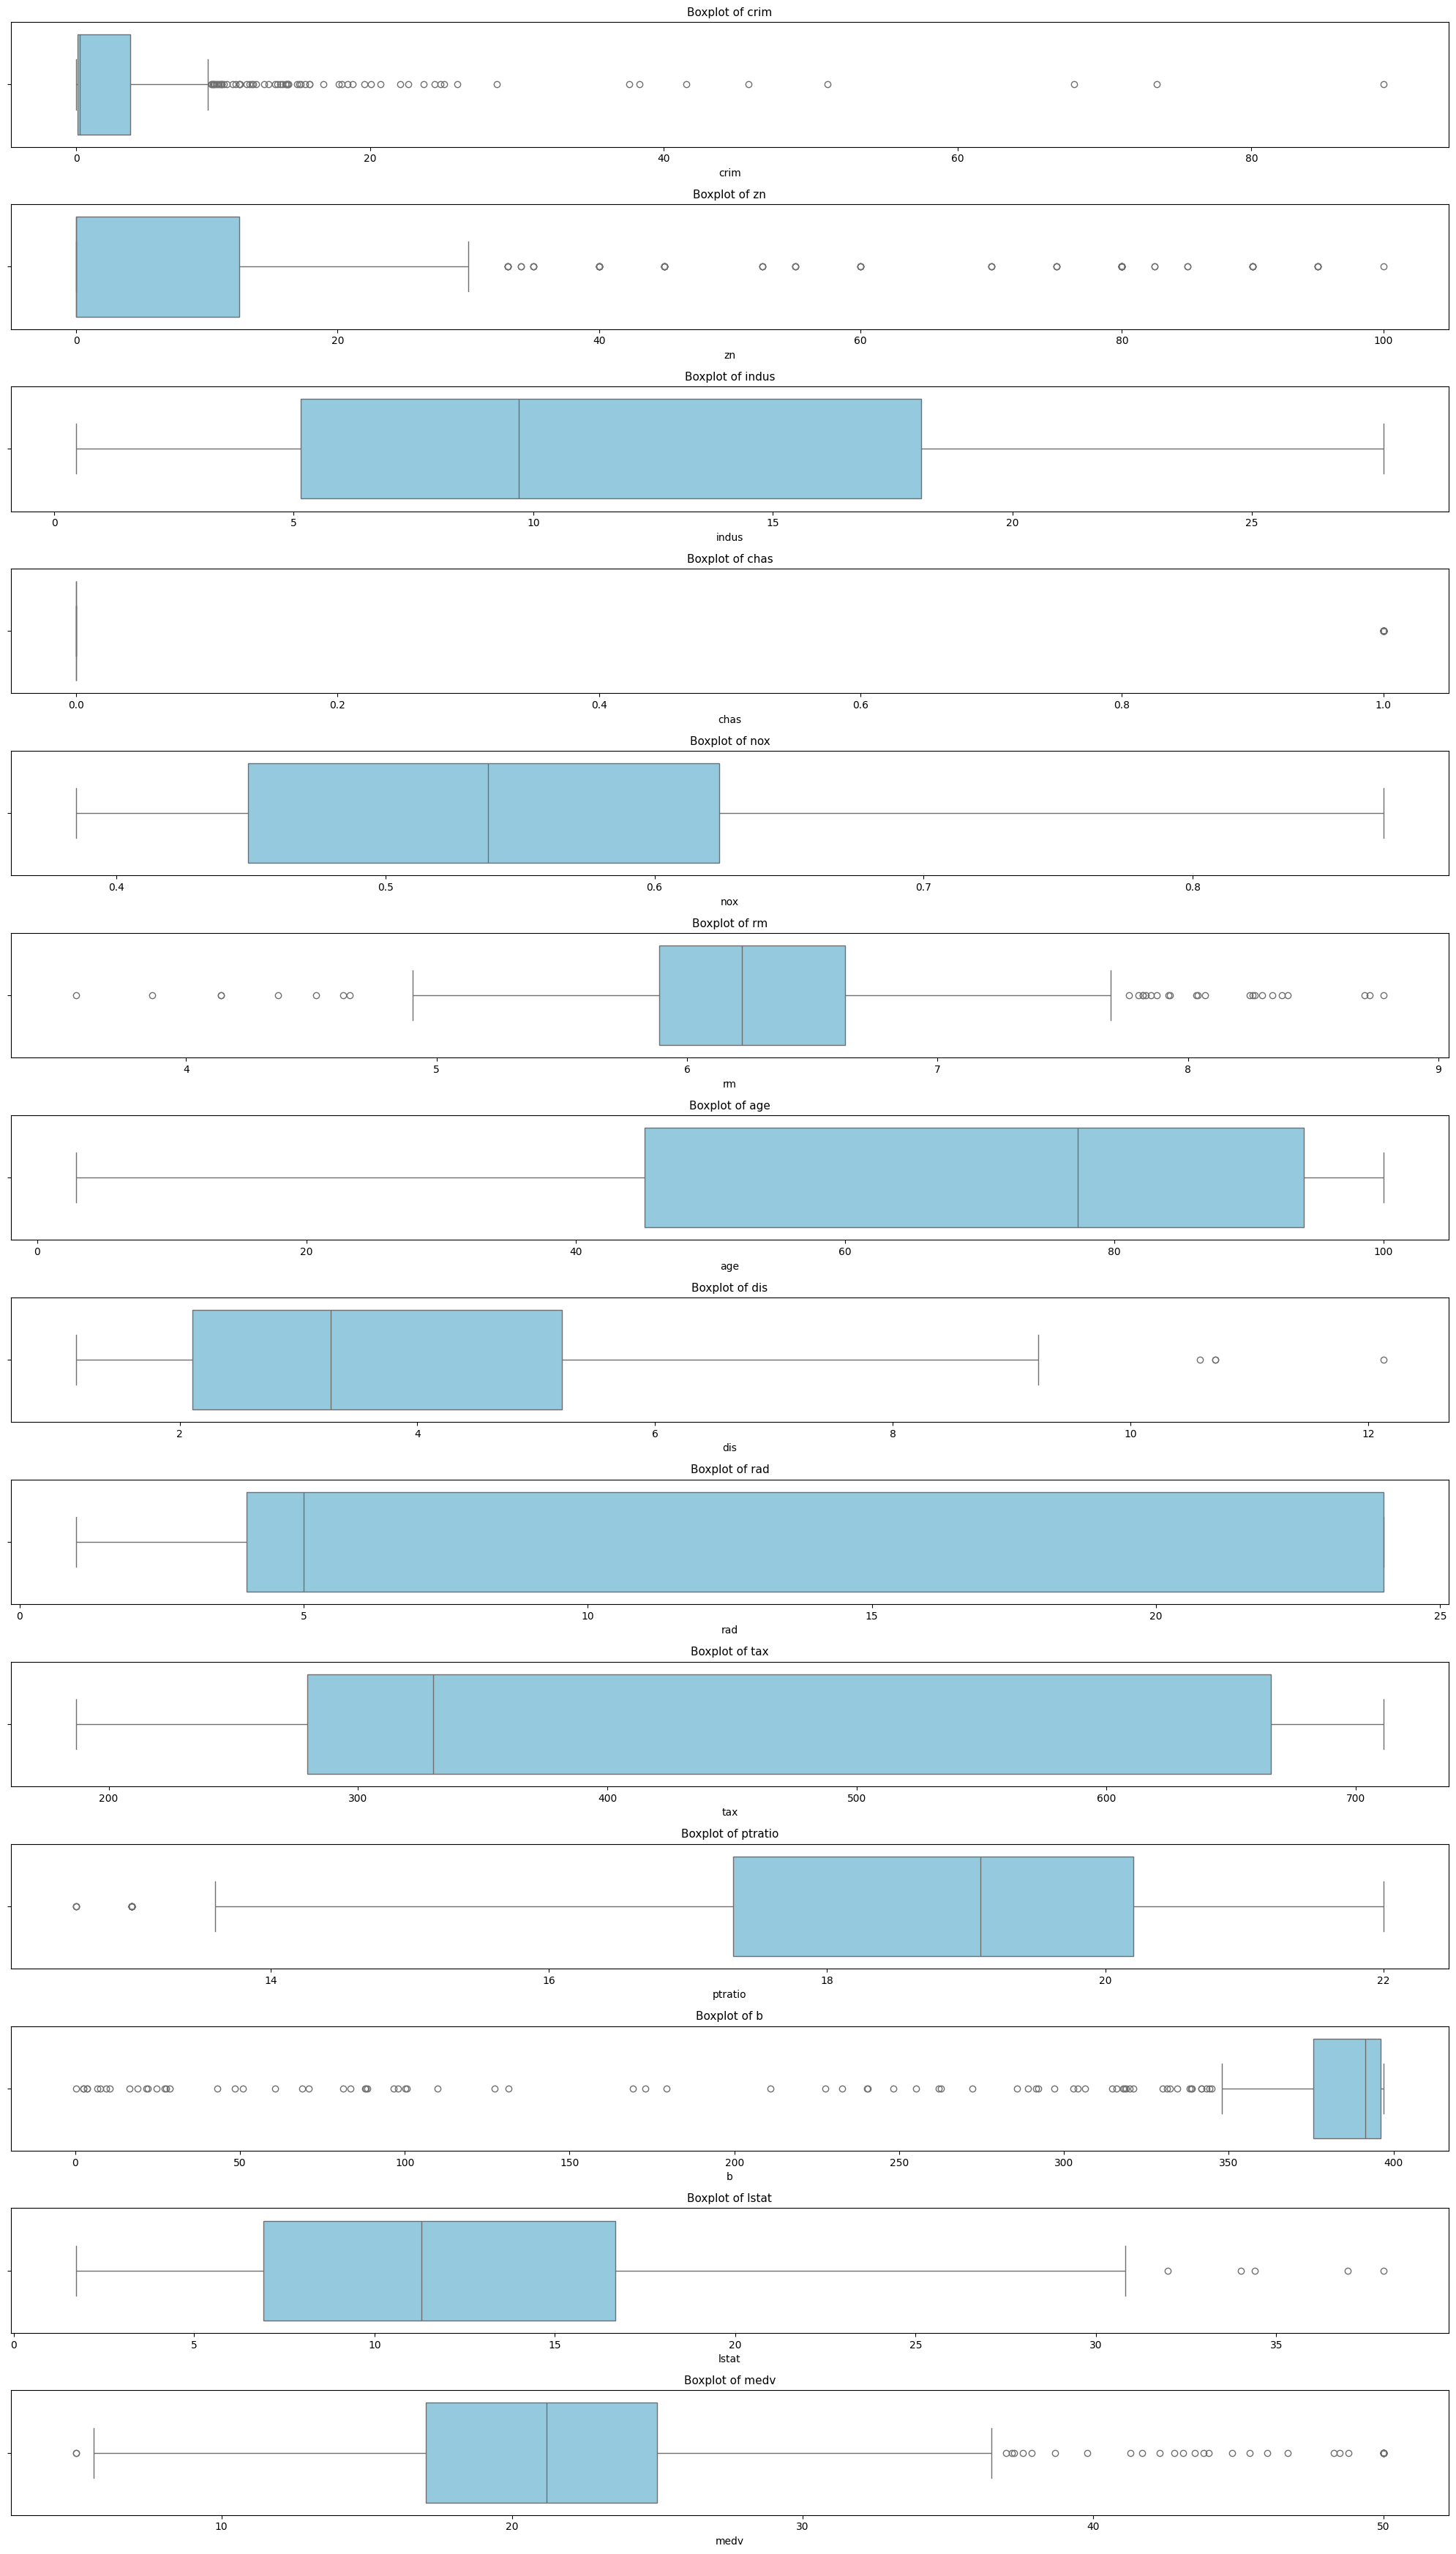


Outlier counts (IQR method):
  crim        : 64 outliers
  zn          : 65 outliers
  indus       : 0 outliers
  chas        : 30 outliers
  nox         : 0 outliers
  rm          : 30 outliers
  age         : 0 outliers
  dis         : 4 outliers
  rad         : 0 outliers
  tax         : 0 outliers
  ptratio     : 14 outliers
  b           : 75 outliers
  lstat       : 5 outliers
  medv        : 40 outliers


In [ ]:
# 9. BOX PLOTS (OUTLIER DETECTION)
# ================================
print("\n" + "=" * 60)
print("BOX PLOTS — OUTLIER DETECTION")
print("=" * 60)

numeric_cols = df_missing.select_dtypes(include=['int64', 'float64']).columns
n = len(numeric_cols)
plt.figure(figsize=(20, n * 2.5))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n, 1, i)
    sns.boxplot(x=df_missing[col], color='skyblue')
    plt.title(f'Boxplot of {col}', fontsize=11)
plt.tight_layout()
plt.savefig("boxplots.png", dpi=150)
plt.show()

# IQR-based outlier count per feature
print("\nOutlier counts (IQR method):")
for col in numeric_cols:
    q1 = df_missing[col].quantile(0.25)
    q3 = df_missing[col].quantile(0.75)
    iqr = q3 - q1
    outliers = df_missing[(df_missing[col] < q1 - 1.5 * iqr) | (df_missing[col] > q3 + 1.5 * iqr)]
    print(f"  {col:<12}: {len(outliers)} outliers")


DENSITY PLOTS


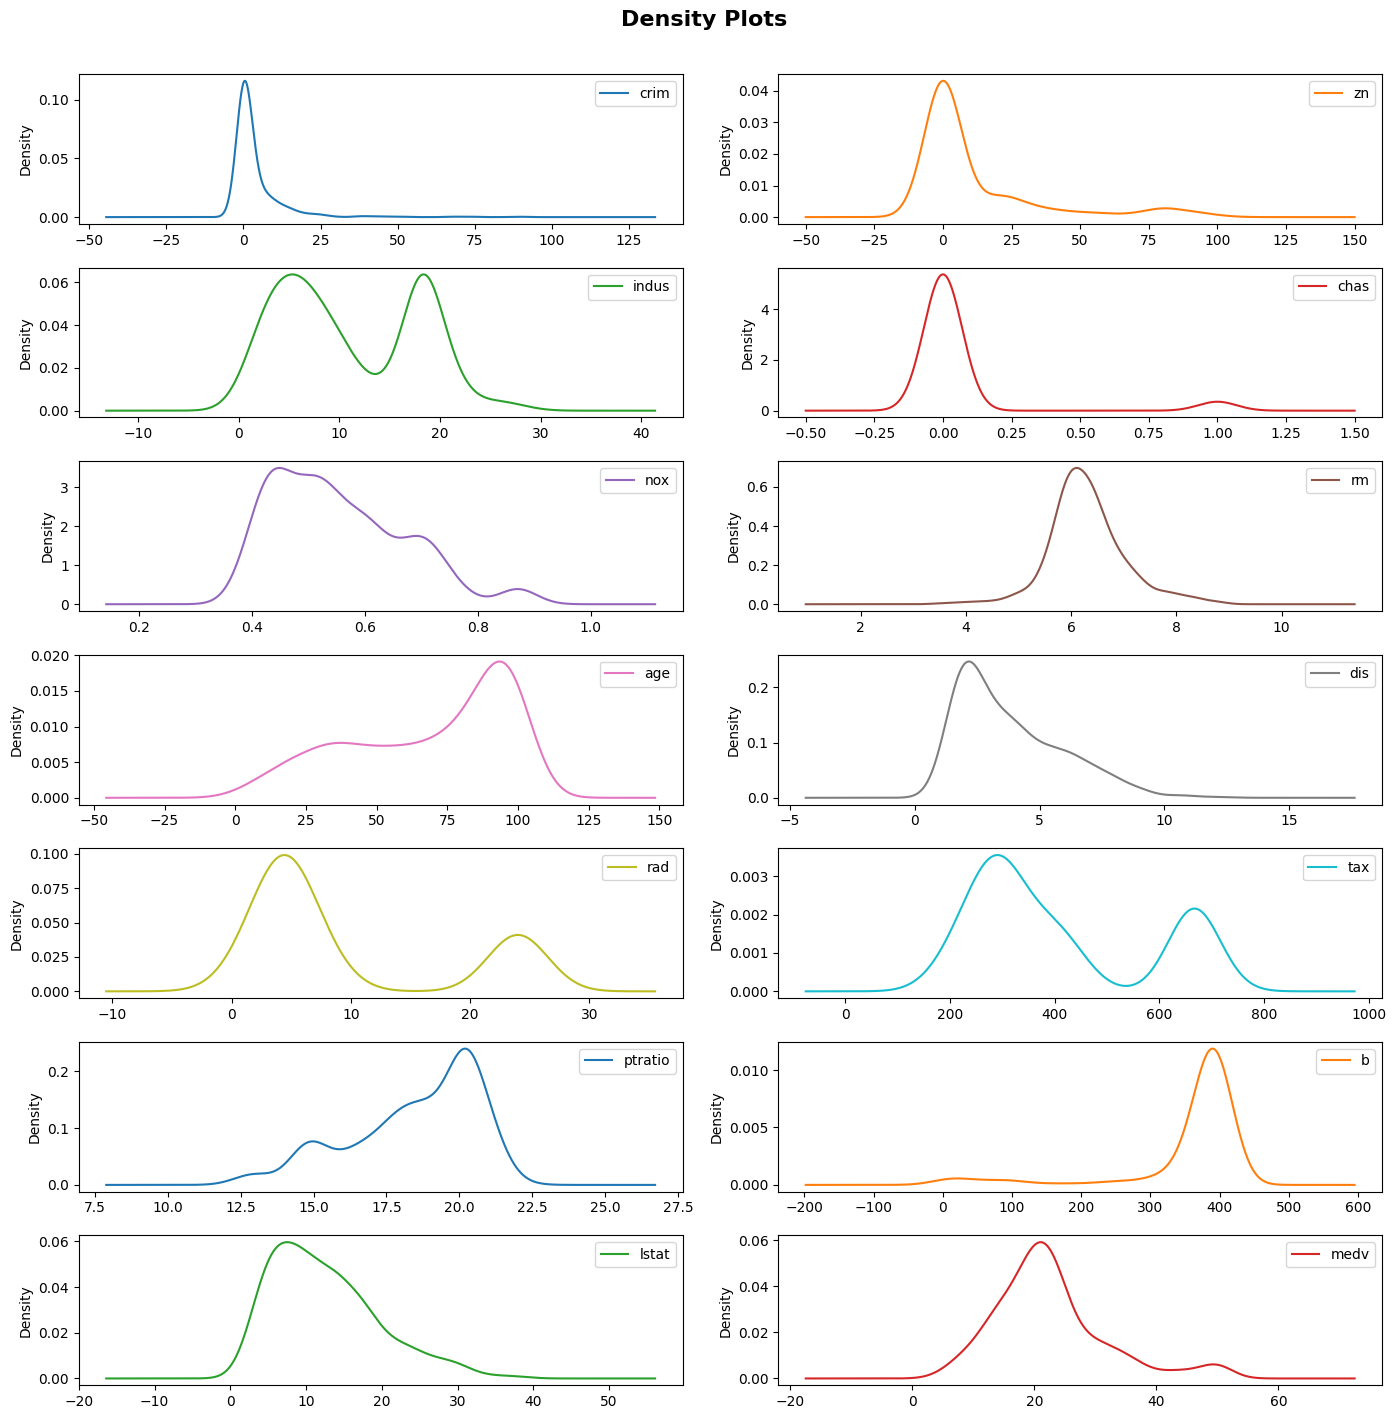

In [ ]:
# 10. DENSITY PLOTS
# ================================
print("\n" + "=" * 60)
print("DENSITY PLOTS")
print("=" * 60)

numerical_data.plot(
    kind='density', figsize=(14, 14),
    subplots=True, layout=(7, 2),
    title="Density Plots of Numerical Features",
    sharex=False
)
plt.suptitle("Density Plots", fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("density_plots.png", dpi=150)
plt.show()

In [ ]:
# 11. UNIQUE VALUE COUNTS
# ================================
print("\n" + "=" * 60)
print("UNIQUE VALUE COUNTS")
print("=" * 60)

print("\nNumber of unique values per numerical feature:")
print(numerical_data.nunique())


UNIQUE VALUE COUNTS

Number of unique values per numerical feature:
crim       481
zn          26
indus       76
chas         2
nox         81
rm         416
age        344
dis        394
rad          9
tax         66
ptratio     46
b          345
lstat      442
medv       229
dtype: int64



CORRELATION ANALYSIS

Pearson Correlation Matrix:
          crim     zn  indus   chas    nox     rm    age    dis    rad    tax  \
crim     1.000 -0.194  0.408 -0.061  0.413 -0.227  0.352 -0.377  0.625  0.604   
zn      -0.194  1.000 -0.545 -0.034 -0.514  0.316 -0.576  0.654 -0.307 -0.314   
indus    0.408 -0.545  1.000  0.084  0.775 -0.382  0.653 -0.708  0.601  0.721   
chas    -0.061 -0.034  0.084  1.000  0.106  0.122  0.076 -0.085 -0.033 -0.022   
nox      0.413 -0.514  0.775  0.106  1.000 -0.306  0.732 -0.771  0.607  0.677   
rm      -0.227  0.316 -0.382  0.122 -0.306  1.000 -0.247  0.202 -0.227 -0.299   
age      0.352 -0.576  0.653  0.076  0.732 -0.247  1.000 -0.742  0.455  0.501   
dis     -0.377  0.654 -0.708 -0.085 -0.771  0.202 -0.742  1.000 -0.493 -0.529   
rad      0.625 -0.307  0.601 -0.033  0.607 -0.227  0.455 -0.493  1.000  0.912   
tax      0.604 -0.314  0.721 -0.022  0.677 -0.299  0.501 -0.529  0.912  1.000   
ptratio  0.289 -0.406  0.375 -0.122  0.194 -0.386  0.284 -

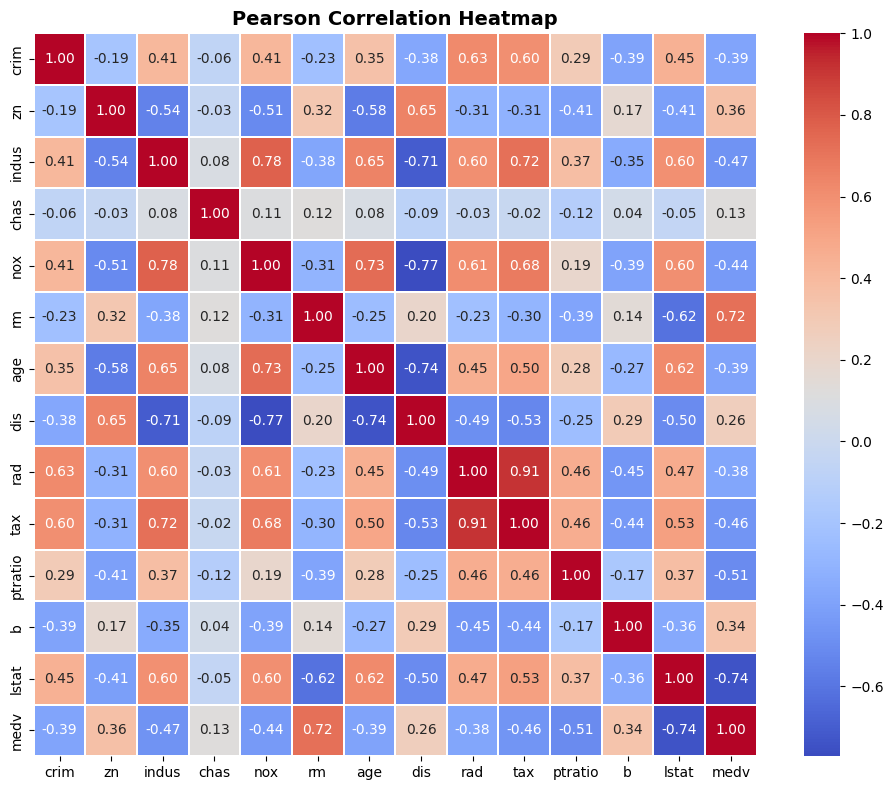

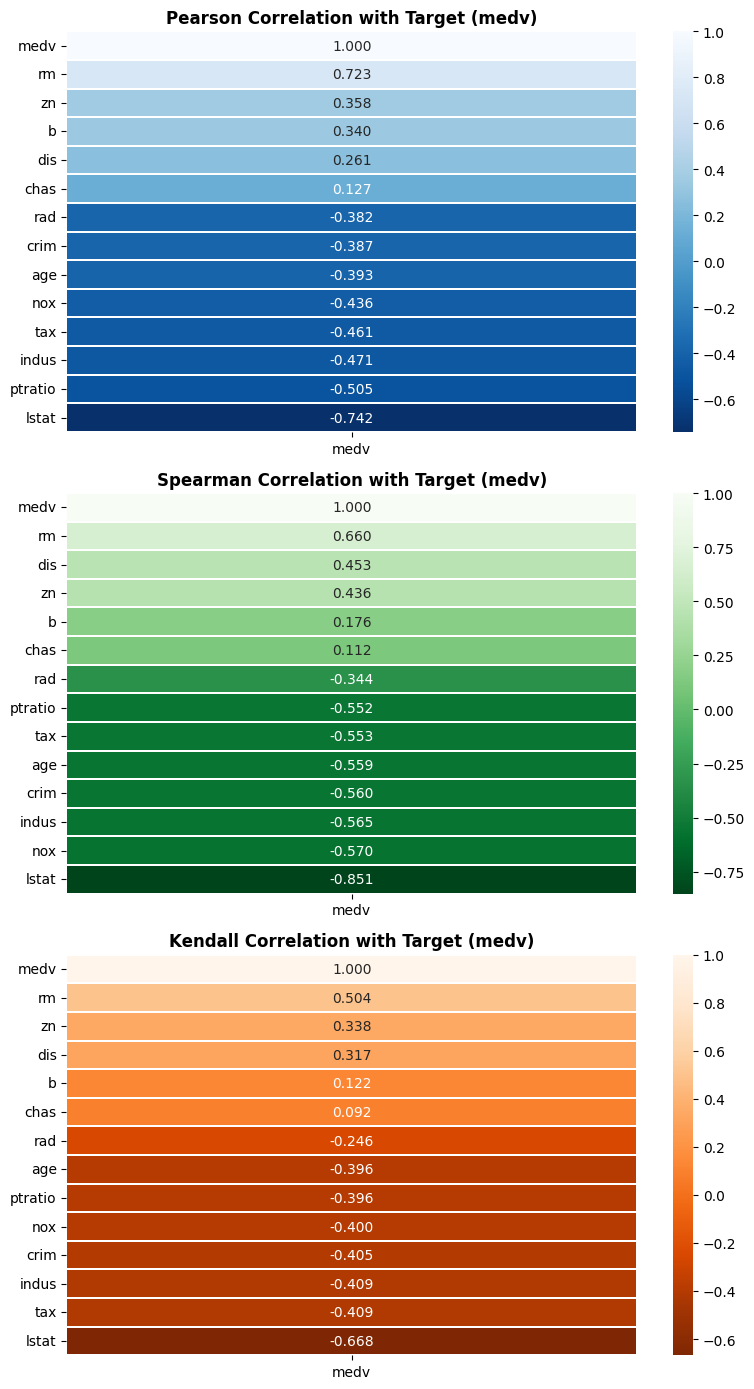

In [ ]:
# 12. CORRELATION ANALYSIS
# ================================
print("\n" + "=" * 60)
print("CORRELATION ANALYSIS")
print("=" * 60)

# Full correlation matrix
correlation_matrix = numerical_data.corr()
print("\nPearson Correlation Matrix:")
print(correlation_matrix.round(3))

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix, annot=True, cmap='coolwarm',
    fmt='.2f', linewidths=0.3, square=True
)
plt.title("Pearson Correlation Heatmap", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()

# Target variable correlation (3 methods)
fig, ax = plt.subplots(3, 1, figsize=(8, 14))
methods = ['pearson', 'spearman', 'kendall']
titles  = ['Pearson', 'Spearman', 'Kendall']
colors  = ['Blues_r', 'Greens_r', 'Oranges_r']

for i, (method, title, cmap) in enumerate(zip(methods, titles, colors)):
    corr = numerical_data.corr(method)[['medv']].sort_values(by='medv', ascending=False)
    sns.heatmap(corr, ax=ax[i], annot=True, cmap=cmap, fmt='.3f', linewidths=0.3)
    ax[i].set_title(f'{title} Correlation with Target (medv)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig("target_correlation.png", dpi=150)
plt.show()



FEATURE vs TARGET SCATTER PLOTS


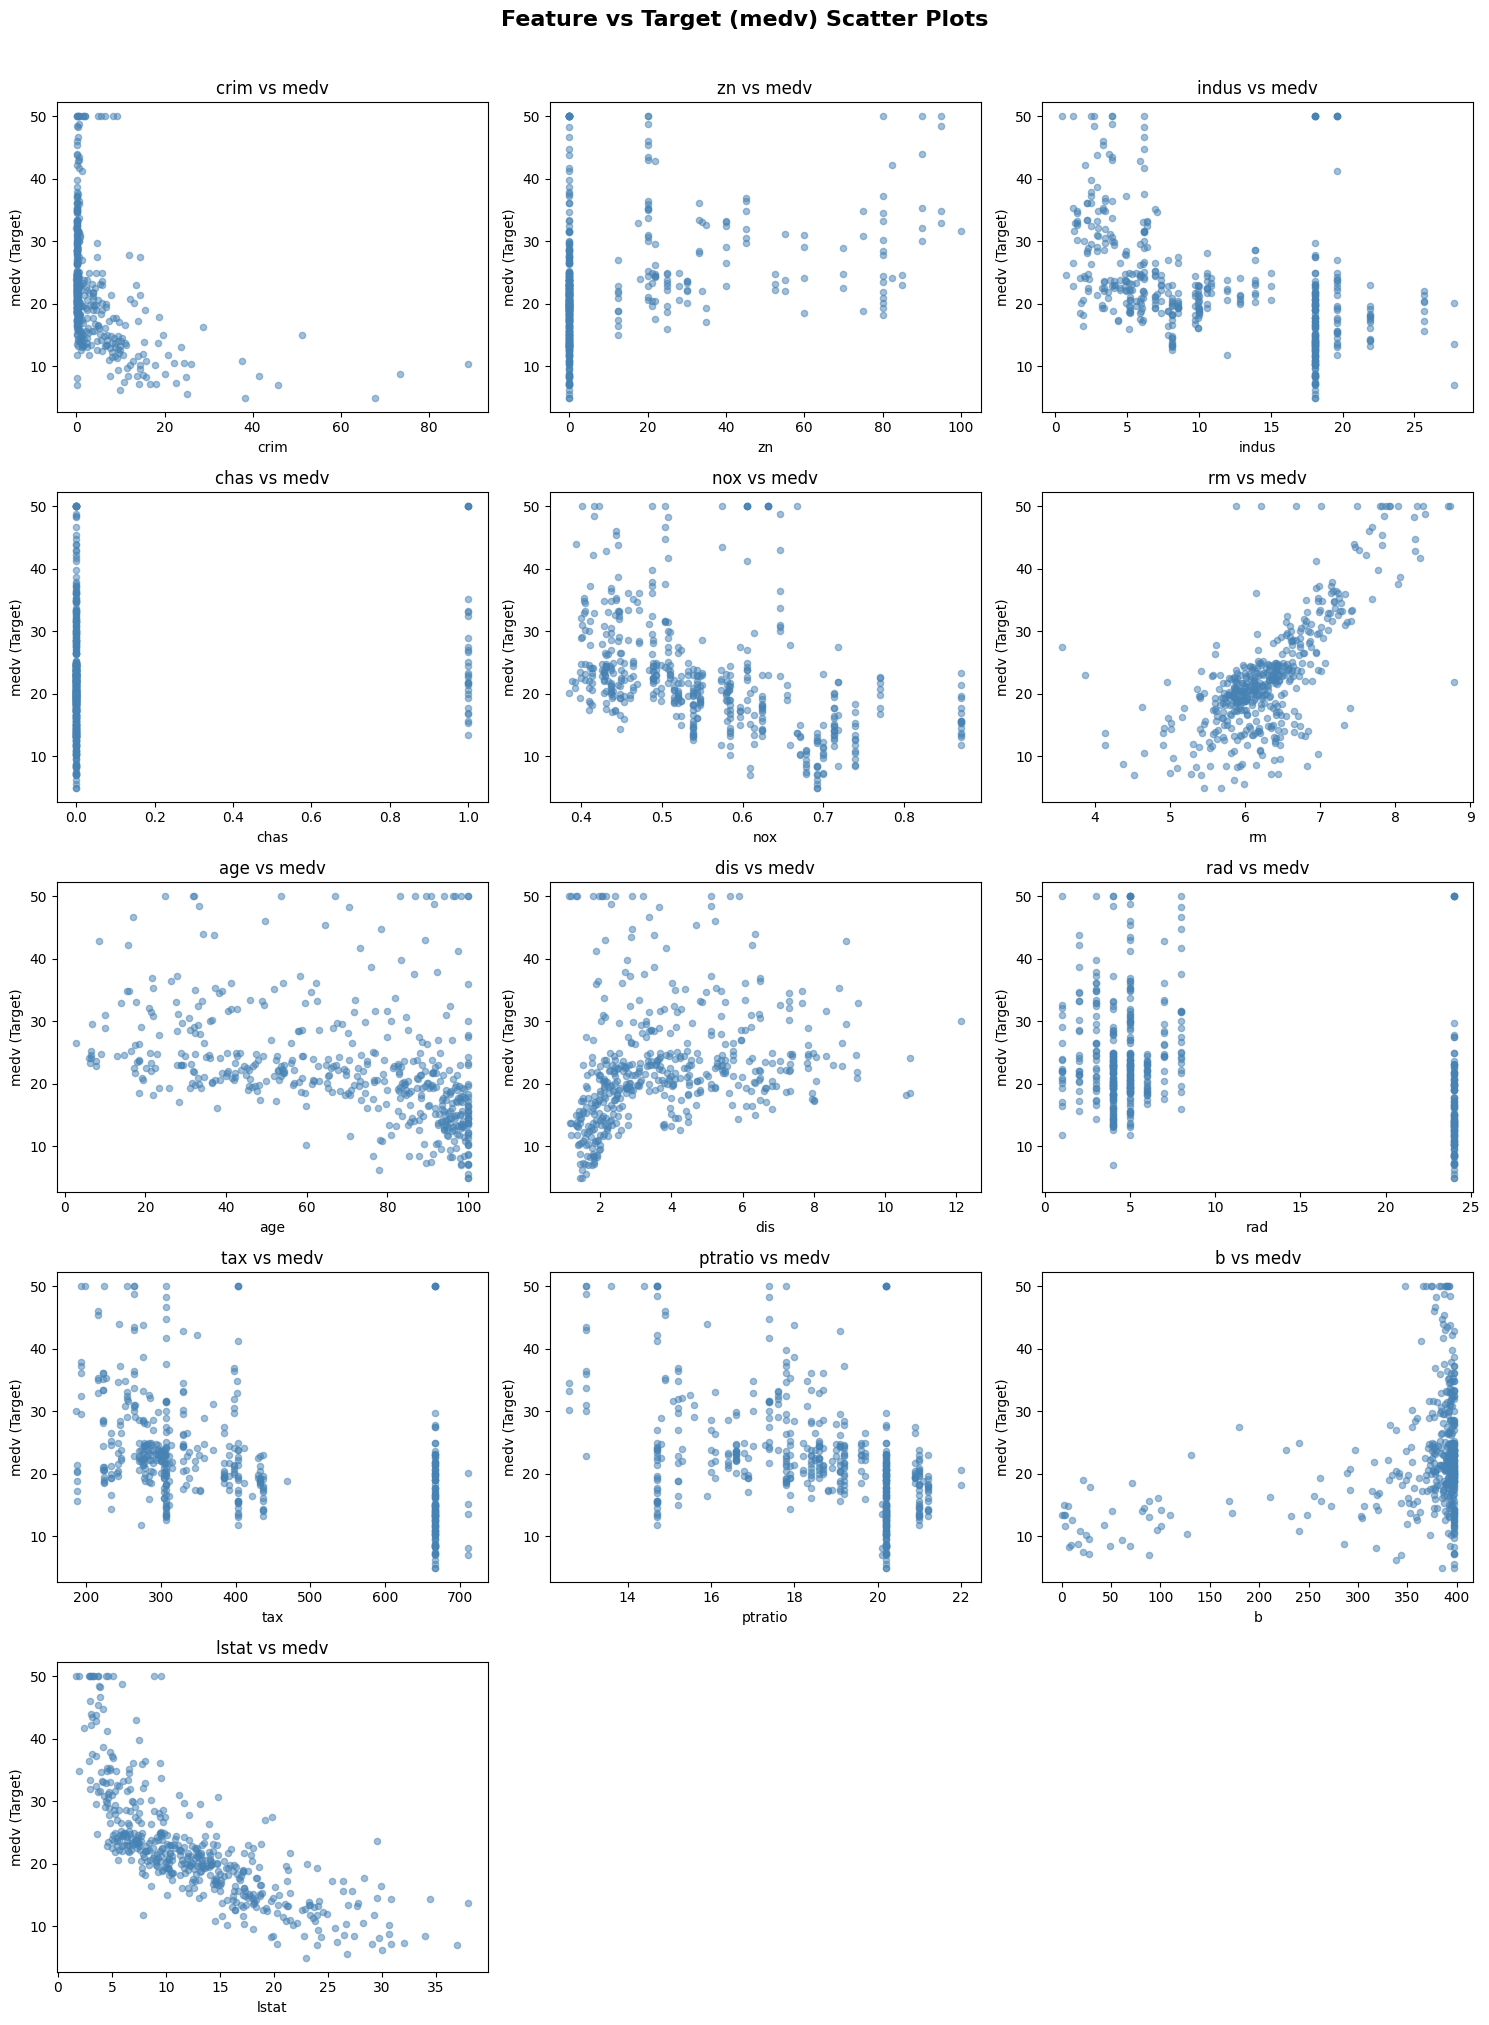

In [ ]:
# 13. FEATURE vs TARGET SCATTER PLOTS
# ================================
print("\n" + "=" * 60)
print("FEATURE vs TARGET SCATTER PLOTS")
print("=" * 60)

feature_cols_no_target = [c for c in numerical_features if c != 'medv']
n_features = len(feature_cols_no_target)
ncols = 3
nrows = (n_features + ncols - 1) // ncols

plt.figure(figsize=(15, nrows * 4))
for i, col in enumerate(feature_cols_no_target, 1):
    plt.subplot(nrows, ncols, i)
    plt.scatter(df_missing[col], df_missing['medv'], alpha=0.5, color='steelblue', s=20)
    plt.xlabel(col)
    plt.ylabel('medv (Target)')
    plt.title(f'{col} vs medv')
plt.suptitle("Feature vs Target (medv) Scatter Plots", fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("scatter_plots.png", dpi=150)
plt.show()


Note: 'chas' column is stored as object/categorical.

Distribution of 'chas' (Charles River dummy variable):
chas
0.0    457
1.0     30
Name: count, dtype: int64

Percentage:
chas
0.0    93.84
1.0     6.16
Name: count, dtype: float64


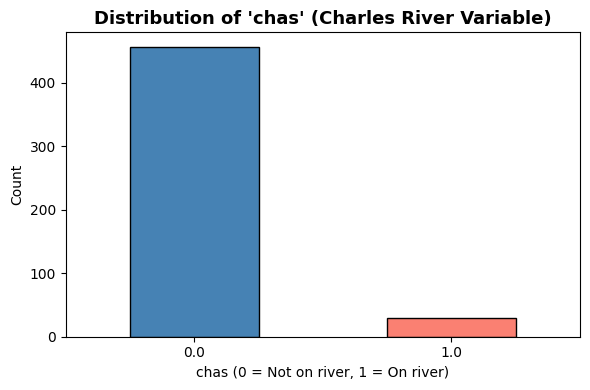

In [ ]:
# 14. CATEGORICAL FEATURE ANALYSIS
# ================================
if categorical_features:
    print("\n" + "=" * 60)
    print("CATEGORICAL FEATURE ANALYSIS")
    print("=" * 60)

    print("\nUnique value counts per categorical feature:")
    print(categorical_data.nunique())

    for col in categorical_features:
        plt.figure(figsize=(8, 4))
        categorical_data[col].value_counts().sort_index().plot(
            kind='bar', rot=0, color='steelblue', edgecolor='black'
        )
        plt.title(f'Distribution of {col}', fontsize=13, fontweight='bold')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.tight_layout()
        plt.savefig(f"catplot_{col}.png", dpi=150)
        plt.show()
else:
    print("\nNote: 'chas' column is stored as object/categorical.")
    print("\nDistribution of 'chas' (Charles River dummy variable):")
    chas_counts = df_missing['chas'].value_counts()
    print(chas_counts)
    chas_pct = chas_counts / chas_counts.sum() * 100
    print("\nPercentage:")
    print(chas_pct.round(2))

    plt.figure(figsize=(6, 4))
    chas_counts.plot(kind='bar', color=['steelblue', 'salmon'], edgecolor='black', rot=0)
    plt.title("Distribution of 'chas' (Charles River Variable)", fontsize=13, fontweight='bold')
    plt.xlabel("chas (0 = Not on river, 1 = On river)")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig("chas_distribution.png", dpi=150)
    plt.show()


In [ ]:
# 15. SUMMARY
# ================================
print("\n" + "=" * 60)
print("EDA SUMMARY")
print("=" * 60)

print(f"""
Shape       : {df_missing.shape[0]} rows × {df_missing.shape[1]} columns
Target      : medv (median house value in $1000s)

Findings:
  - crim, lstat, chas are highly right-skewed → may need log transform
  - rm has strong positive correlation with medv (Pearson ≈ 0.70)
  - lstat has strong negative correlation with medv (Pearson ≈ -0.74)
  - chas shows moderate class imbalance (most = 0, not on river)
  - Several features (crim, b, zn) have notable outliers via IQR

""")


EDA SUMMARY

Shape       : 506 rows × 14 columns
Target      : medv (median house value in $1000s)

Findings:
  - crim, lstat, chas are highly right-skewed → may need log transform
  - rm has strong positive correlation with medv (Pearson ≈ 0.70)
  - lstat has strong negative correlation with medv (Pearson ≈ -0.74)
  - chas shows moderate class imbalance (most = 0, not on river)
  - Several features (crim, b, zn) have notable outliers via IQR




In [ ]:
!pip install --quiet catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

np.random.seed(42)

print("df_missing recreated. Shape:", df_missing.shape)
print("Missing values:\n", df_missing.isnull().sum()[df_missing.isnull().sum() > 0])

df_missing recreated. Shape: (506, 14)
Missing values:
 crim       23
zn         23
indus      28
chas       19
nox        16
rm         35
age        17
dis        25
rad        19
tax        34
ptratio    12
b          22
lstat      22
dtype: int64


In [ ]:
# STEP 1 — MEDIAN IMPUTATION
# ============================================================
print("\n" + "=" * 60)
print("STEP 1: MEDIAN IMPUTATION")
print("=" * 60)

imputer = SimpleImputer(strategy='median')
df_imputed = df_missing.copy()

# Impute only numeric columns (exclude chas which is object)
numeric_cols = df_missing.select_dtypes(include='number').columns
df_imputed[numeric_cols] = imputer.fit_transform(df_missing[numeric_cols])

print("Missing values after imputation:")
print(df_imputed.isnull().sum())
print("\nMedian values used for imputation:")
for col, med in zip(numeric_cols, imputer.statistics_):
    print(f"  {col:<12}: {med:.4f}")

df_imputed.head(100)


STEP 1: MEDIAN IMPUTATION
Missing values after imputation:
crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

Median values used for imputation:
  crim        : 0.2591
  zn          : 0.0000
  indus       : 9.6900
  chas        : 0.0000
  nox         : 0.5380
  rm          : 6.2190
  age         : 77.3000
  dis         : 3.2721
  rad         : 5.0000
  tax         : 330.0000
  ptratio     : 19.1000
  b           : 391.3400
  lstat       : 11.3000
  medv        : 21.2000


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,391.34,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,11.30,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.12204,0.0,2.89,0.0,0.445,6.625,57.8,3.4952,2.0,276.0,18.0,357.98,6.65,28.4
96,0.11504,0.0,2.89,0.0,0.445,6.163,69.6,3.4952,2.0,276.0,18.0,391.34,11.34,21.4
97,0.12083,0.0,2.89,0.0,0.445,8.069,76.0,3.4952,2.0,276.0,18.0,396.90,4.21,38.7
98,0.08187,0.0,2.89,0.0,0.445,7.820,36.9,3.4952,2.0,276.0,18.0,393.53,3.57,43.8


In [ ]:
# STEP 2 — ENCODE 'chas' AS INTEGER
# ============================================================
print("\n" + "=" * 60)
print("STEP 2: ENCODE 'chas' AS INTEGER")
print("=" * 60)

df_imputed['chas'] = df_imputed['chas'].astype(float).astype(int)
print("'chas' dtype after encoding:", df_imputed['chas'].dtype)
print("'chas' value counts:\n", df_imputed['chas'].value_counts())


STEP 2: ENCODE 'chas' AS INTEGER
'chas' dtype after encoding: int64
'chas' value counts:
 chas
0    476
1     30
Name: count, dtype: int64



STEP 2.5: SMOTE BALANCING ON 'chas'

Class distribution BEFORE SMOTE:
chas
0    476
1     30
Name: count, dtype: int64
  Ratio (1s vs total): 0.059

Class distribution AFTER SMOTE:
chas
0    476
1    476
Name: count, dtype: int64
  Ratio (1s vs total): 0.500

Dataset size before SMOTE: 506 rows
Dataset size after  SMOTE: 952 rows


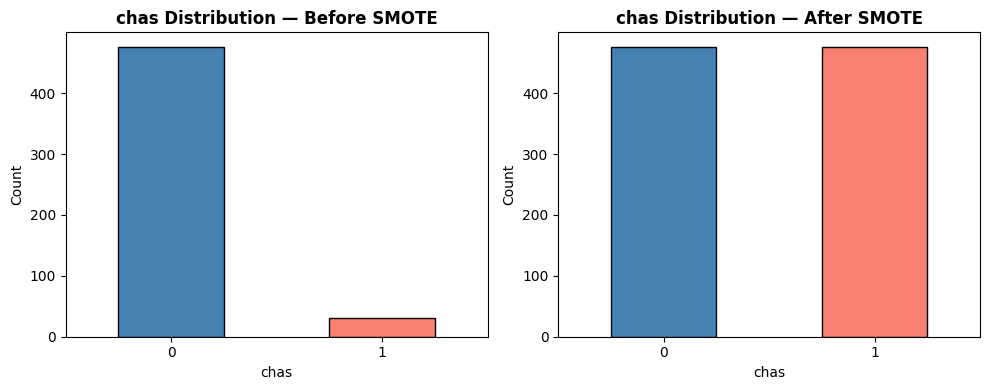

In [ ]:
# STEP 2.5 — SMOTE BALANCING ON 'chas'
# ============================================================
print("\n" + "=" * 60)
print("STEP 2.5: SMOTE BALANCING ON 'chas'")
print("=" * 60)

from imblearn.over_sampling import SMOTE

print("\nClass distribution BEFORE SMOTE:")
print(df_imputed['chas'].value_counts())
print(f"  Ratio (1s vs total): {df_imputed['chas'].mean():.3f}")

# Separate features and chas as the label to balance on
# Keep medv separate — SMOTE should not treat it as a feature
X_smote = df_imputed.drop(columns=['medv', 'chas'])
y_smote = df_imputed['chas']
medv_values = df_imputed['medv'].values

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_smote, y_smote)

# For the synthetic rows, medv is not available — we fill with median
n_synthetic = len(X_resampled) - len(X_smote)
medv_synthetic = np.full(n_synthetic, np.median(medv_values))
medv_full = np.concatenate([medv_values, medv_synthetic])

# Rebuild df_imputed from resampled data
df_imputed = pd.DataFrame(X_resampled, columns=X_smote.columns)
df_imputed['chas'] = y_resampled.values
df_imputed['medv'] = medv_full

print("\nClass distribution AFTER SMOTE:")
print(df_imputed['chas'].value_counts())
print(f"  Ratio (1s vs total): {df_imputed['chas'].mean():.3f}")
print(f"\nDataset size before SMOTE: {len(X_smote)} rows")
print(f"Dataset size after  SMOTE: {len(df_imputed)} rows")

# Bar chart before vs after
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
y_smote.value_counts().sort_index().plot(kind='bar', ax=axes[0], color=['steelblue','salmon'], edgecolor='black', rot=0)
axes[0].set_title("chas Distribution — Before SMOTE", fontweight='bold')
axes[0].set_xlabel("chas")
axes[0].set_ylabel("Count")

df_imputed['chas'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color=['steelblue','salmon'], edgecolor='black', rot=0)
axes[1].set_title("chas Distribution — After SMOTE", fontweight='bold')
axes[1].set_xlabel("chas")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("smote_balance.png", dpi=150)
plt.show()

In [ ]:
df_imputed.head(100)

,crim,zn,indus,nox,rm,age,dis,rad,tax,ptratio,b,lstat,chas,medv
0,0.00632,18.0,2.31,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,0,24.0
1,0.02731,0.0,7.07,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,391.34,9.14,0,21.6
2,0.02729,0.0,7.07,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,0,34.7
3,0.03237,0.0,2.18,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,0,33.4
4,0.06905,0.0,2.18,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,11.30,0,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.12204,0.0,2.89,0.445,6.625,57.8,3.4952,2.0,276.0,18.0,357.98,6.65,0,28.4
96,0.11504,0.0,2.89,0.445,6.163,69.6,3.4952,2.0,276.0,18.0,391.34,11.34,0,21.4
97,0.12083,0.0,2.89,0.445,8.069,76.0,3.4952,2.0,276.0,18.0,396.90,4.21,0,38.7
98,0.08187,0.0,2.89,0.445,7.820,36.9,3.4952,2.0,276.0,18.0,393.53,3.57,0,43.8



STEP 3: LOG TRANSFORM SKEWED FEATURES
Features to transform: ['crim', 'zn', 'lstat', 'b']

Skewness BEFORE transform:
  crim    : 6.931
  zn      : 2.598
  lstat   : 0.954
  b       : -3.917

Skewness AFTER log1p transform:
  crim    : 1.507
  zn      : 1.374
  lstat   : -0.269
  b       : -6.199


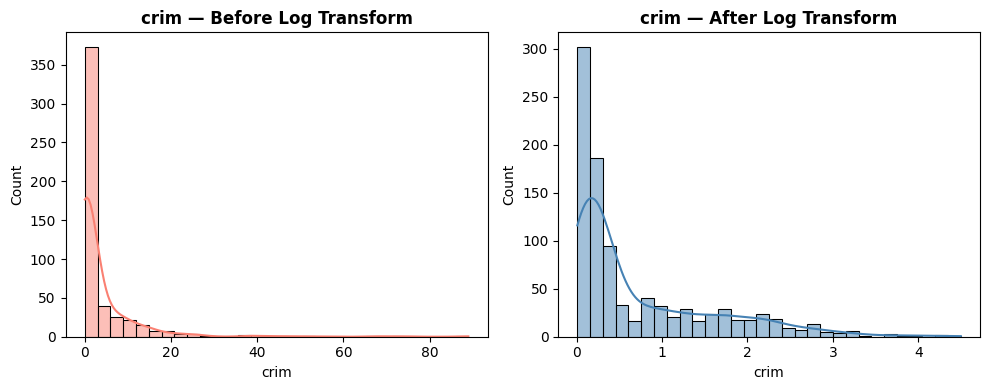

In [ ]:
# STEP 3 — LOG TRANSFORM SKEWED FEATURES
# ============================================================
print("\n" + "=" * 60)
print("STEP 3: LOG TRANSFORM SKEWED FEATURES")
print("=" * 60)

skewed_features = ['crim', 'zn', 'lstat', 'b']
print(f"Features to transform: {skewed_features}")

print("\nSkewness BEFORE transform:")
for col in skewed_features:
    print(f"  {col:<8}: {df_imputed[col].skew():.3f}")

for col in skewed_features:
    df_imputed[col] = np.log1p(df_imputed[col])

print("\nSkewness AFTER log1p transform:")
for col in skewed_features:
    print(f"  {col:<8}: {df_imputed[col].skew():.3f}")

# Plot before vs after for one feature (crim) as example
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(df[('crim')], bins=30, ax=axes[0], color='salmon', kde=True)
axes[0].set_title("crim — Before Log Transform", fontweight='bold')
sns.histplot(df_imputed['crim'], bins=30, ax=axes[1], color='steelblue', kde=True)
axes[1].set_title("crim — After Log Transform", fontweight='bold')
plt.tight_layout()
plt.savefig("log_transform_crim.png", dpi=150)
plt.show()


STEP 4: FEATURE SELECTION

Absolute correlation with target (medv):
lstat      0.620
rm         0.494
crim       0.382
indus      0.376
ptratio    0.366
age        0.326
tax        0.320
nox        0.302
zn         0.301
rad        0.284
b          0.263
dis        0.246
chas       0.052
Name: medv, dtype: float64

Dropping weak features (|corr| < 0.15): ['chas']

Checking multicollinearity (rad vs tax):
  Pearson corr(rad, tax) = 0.856
  → Dropping 'rad' (lower correlation with target than 'tax')

Features kept (11): ['crim', 'zn', 'indus', 'nox', 'rm', 'age', 'dis', 'tax', 'ptratio', 'b', 'lstat']


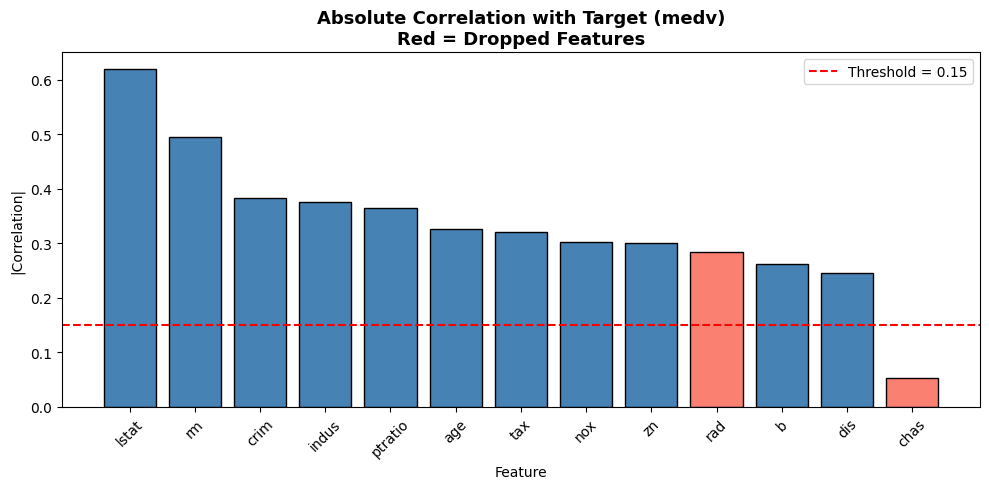

In [ ]:
# STEP 4 — FEATURE SELECTION
# ============================================================
print("\n" + "=" * 60)
print("STEP 4: FEATURE SELECTION")
print("=" * 60)

# Correlation with target
corr_with_target = df_imputed.corr()['medv'].drop('medv').abs().sort_values(ascending=False)
print("\nAbsolute correlation with target (medv):")
print(corr_with_target.round(3))

# Drop weak features (|corr| < 0.15)
weak_features = corr_with_target[corr_with_target < 0.15].index.tolist()
print(f"\nDropping weak features (|corr| < 0.15): {weak_features}")

# Check multicollinearity — rad & tax are highly correlated (~0.91)
print("\nChecking multicollinearity (rad vs tax):")
print(f"  Pearson corr(rad, tax) = {df_imputed['rad'].corr(df_imputed['tax']):.3f}")
print("  → Dropping 'rad' (lower correlation with target than 'tax')")

drop_cols = weak_features + ['rad']
df_selected = df_imputed.drop(columns=drop_cols)

print(f"\nFeatures kept ({len(df_selected.columns) - 1}):", [c for c in df_selected.columns if c != 'medv'])

# Bar chart of correlations
plt.figure(figsize=(10, 5))
colors = ['steelblue' if c not in drop_cols else 'salmon' for c in corr_with_target.index]
plt.bar(corr_with_target.index, corr_with_target.values, color=colors, edgecolor='black')
plt.axhline(0.15, color='red', linestyle='--', label='Threshold = 0.15')
plt.title("Absolute Correlation with Target (medv)\nRed = Dropped Features", fontsize=13, fontweight='bold')
plt.xlabel("Feature")
plt.ylabel("|Correlation|")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig("feature_selection.png", dpi=150)
plt.show()

In [ ]:
# STEP 5 — STANDARD SCALING + TRAIN/TEST SPLIT
# ============================================================
print("\n" + "=" * 60)
print("STEP 5: STANDARD SCALING")
print("=" * 60)

X = df_selected.drop(columns=['medv'])
y = df_selected['medv']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X.columns)

print("\nFeature means after scaling (should be ~0):")
print(X_train_scaled.mean().round(4))
print("\nFeature stds after scaling (should be ~1):")
print(X_train_scaled.std().round(4))


STEP 5: STANDARD SCALING
Train size: (761, 11), Test size: (191, 11)

Feature means after scaling (should be ~0):
crim       0.0
zn         0.0
indus     -0.0
nox       -0.0
rm        -0.0
age        0.0
dis        0.0
tax        0.0
ptratio    0.0
b          0.0
lstat     -0.0
dtype: float64

Feature stds after scaling (should be ~1):
crim       1.0007
zn         1.0007
indus      1.0007
nox        1.0007
rm         1.0007
age        1.0007
dis        1.0007
tax        1.0007
ptratio    1.0007
b          1.0007
lstat      1.0007
dtype: float64


In [ ]:
# HELPER: Evaluation Function
# ============================================================
def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"\n  {'RMSE':<6}: {rmse:.4f}")
    print(f"  {'MAE':<6}: {mae:.4f}")
    print(f"  {'R²':<6}: {r2:.4f}")
    return {"Model": name, "RMSE": round(rmse, 4), "MAE": round(mae, 4), "R²": round(r2, 4)}

results = []


STEP 6: CATBOOST
0:	learn: 7.0600887	total: 50.6ms	remaining: 25.3s
100:	learn: 3.0670253	total: 331ms	remaining: 1.31s
200:	learn: 2.3155173	total: 607ms	remaining: 903ms
300:	learn: 1.8780433	total: 909ms	remaining: 601ms
400:	learn: 1.6044400	total: 1.2s	remaining: 295ms
499:	learn: 1.3882017	total: 1.47s	remaining: 0us

CatBoost Results:

  RMSE  : 2.1341
  MAE   : 1.4586
  R²    : 0.7606


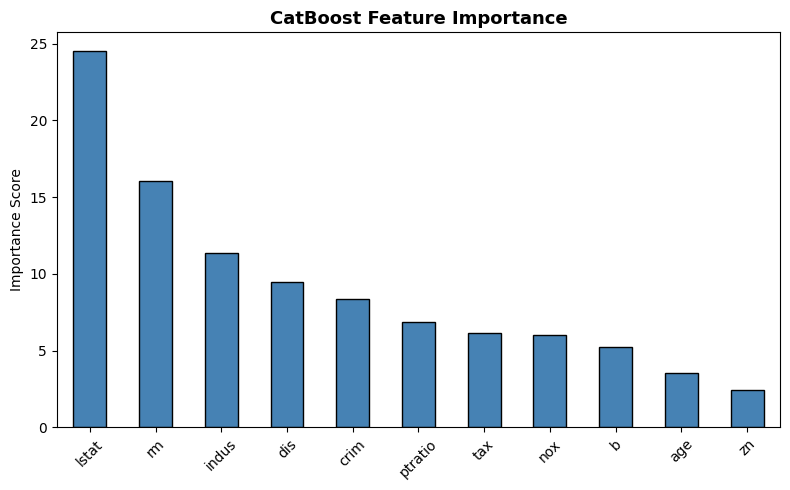

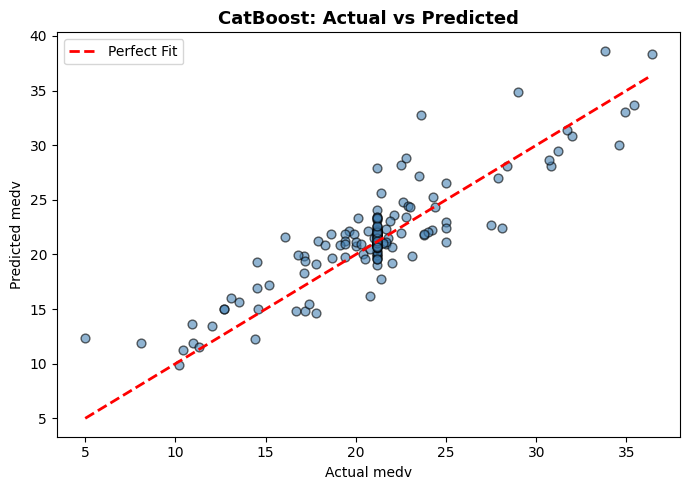

In [ ]:
# STEP 6 — CATBOOST
# ============================================================
print("\n" + "=" * 60)
print("STEP 6: CATBOOST")
print("=" * 60)

catboost = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    random_seed=42,
    verbose=100
)
catboost.fit(X_train_scaled, y_train)

y_pred_cat = catboost.predict(X_test_scaled)
print("\nCatBoost Results:")
results.append(evaluate("CatBoost", y_test, y_pred_cat))

# Feature importance
feat_imp = pd.Series(catboost.get_feature_importance(), index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
feat_imp.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title("CatBoost Feature Importance", fontsize=13, fontweight='bold')
plt.ylabel("Importance Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("catboost_feature_importance.png", dpi=150)
plt.show()

# Actual vs Predicted
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_cat, alpha=0.6, color='steelblue', edgecolors='black', s=40)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit')
plt.xlabel("Actual medv")
plt.ylabel("Predicted medv")
plt.title("CatBoost: Actual vs Predicted", fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig("catboost_actual_vs_pred.png", dpi=150)
plt.show()

In [ ]:
# STEP 7 — ENSEMBLE LEARNING
# ============================================================
print("\n" + "=" * 60)
print("STEP 7: ENSEMBLE LEARNING")
print("=" * 60)

print("\n--- Training Random Forest ---")
rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
print("Random Forest Results:")
results.append(evaluate("Random Forest", y_test, y_pred_rf))

print("\n--- Training XGBoost ---")
xgb = XGBRegressor(
    n_estimators=500, learning_rate=0.05,
    max_depth=6, random_state=42, verbosity=0
)
xgb.fit(X_train_scaled, y_train)
y_pred_xgb = xgb.predict(X_test_scaled)
print("XGBoost Results:")
results.append(evaluate("XGBoost", y_test, y_pred_xgb))



# --- Gradient Boosting Regressor ---
print("\n--- Training Gradient Boosting Regressor ---")

from sklearn.ensemble import GradientBoostingRegressor, ExtraTreesRegressor

gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gbr.fit(X_train_scaled, y_train)
y_pred_gbr = gbr.predict(X_test_scaled)

print("Gradient Boosting Results:")
results.append(evaluate("Gradient Boosting", y_test, y_pred_gbr))


# --- Extra Trees Regressor ---
print("\n--- Training Extra Trees Regressor ---")

et = ExtraTreesRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

et.fit(X_train_scaled, y_train)
y_pred_et = et.predict(X_test_scaled)

print("Extra Trees Results:")
results.append(evaluate("Extra Trees", y_test, y_pred_et))


# --- Max Voting Ensemble (all 5 models) ---
print("\n--- Max Voting Ensemble (RF + XGB + CatBoost + GBR + ET) ---")
# For each row, pick the highest prediction among all 5 models
all_preds = np.column_stack([y_pred_rf, y_pred_xgb, y_pred_cat, y_pred_gbr, y_pred_et])
y_pred_maxvote = np.max(all_preds, axis=1)
print("Max Voting Ensemble Results:")
results.append(evaluate("Max Voting Ensemble", y_test, y_pred_maxvote))

# --- Stacking Ensemble (all 5 models) ---
print("\n--- Stacking Ensemble (meta-model: Ridge Regression) ---")
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_predict

# OOF (out-of-fold) predictions for all 5 models
oof_rf  = cross_val_predict(RandomForestRegressor(n_estimators=100, random_state=42), X_train_scaled, y_train, cv=5)
oof_xgb = cross_val_predict(XGBRegressor(n_estimators=200, learning_rate=0.05, random_state=42, verbosity=0), X_train_scaled, y_train, cv=5)
oof_cat = cross_val_predict(CatBoostRegressor(iterations=200, learning_rate=0.05, random_seed=42, verbose=0), X_train_scaled, y_train, cv=5)
oof_gbr = cross_val_predict(GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42), X_train_scaled, y_train, cv=5)
oof_et  = cross_val_predict(ExtraTreesRegressor(n_estimators=100, random_state=42, n_jobs=-1), X_train_scaled, y_train, cv=5)

# Stack all 5 OOF preds as meta-features (5 columns)
meta_train = np.column_stack([oof_rf, oof_xgb, oof_cat, oof_gbr, oof_et])
meta_test  = np.column_stack([y_pred_rf, y_pred_xgb, y_pred_cat, y_pred_gbr, y_pred_et])

meta_model = Ridge(alpha=1.0)
meta_model.fit(meta_train, y_train)
y_pred_stack = meta_model.predict(meta_test)

print("Stacking Ensemble Results:")
results.append(evaluate("Stacking Ensemble", y_test, y_pred_stack))


STEP 7: ENSEMBLE LEARNING

--- Training Random Forest ---
Random Forest Results:

  RMSE  : 2.2463
  MAE   : 1.4445
  R²    : 0.7347

--- Training XGBoost ---
XGBoost Results:

  RMSE  : 2.2988
  MAE   : 1.4586
  R²    : 0.7222

--- Training Gradient Boosting Regressor ---
Gradient Boosting Results:

  RMSE  : 2.2744
  MAE   : 1.5798
  R²    : 0.7280

--- Training Extra Trees Regressor ---
Extra Trees Results:

  RMSE  : 1.9209
  MAE   : 1.2396
  R²    : 0.8060

--- Max Voting Ensemble (RF + XGB + CatBoost + GBR + ET) ---
Max Voting Ensemble Results:

  RMSE  : 2.6063
  MAE   : 1.8025
  R²    : 0.6429

--- Stacking Ensemble (meta-model: Ridge Regression) ---
Stacking Ensemble Results:

  RMSE  : 2.0965
  MAE   : 1.3693
  R²    : 0.7689



FINAL MODEL COMPARISON

                        RMSE     MAE      R²
Model                                      
CatBoost             2.1341  1.4586  0.7606
Random Forest        2.2463  1.4445  0.7347
XGBoost              2.2988  1.4586  0.7222
Gradient Boosting    2.2744  1.5798  0.7280
Extra Trees          1.9209  1.2396  0.8060
Max Voting Ensemble  2.6063  1.8025  0.6429
Stacking Ensemble    2.0965  1.3693  0.7689
Random Forest        2.2463  1.4445  0.7347
XGBoost              2.2988  1.4586  0.7222
Gradient Boosting    2.2744  1.5798  0.7280
Extra Trees          1.9209  1.2396  0.8060
Max Voting Ensemble  2.6063  1.8025  0.6429
Stacking Ensemble    2.0965  1.3693  0.7689


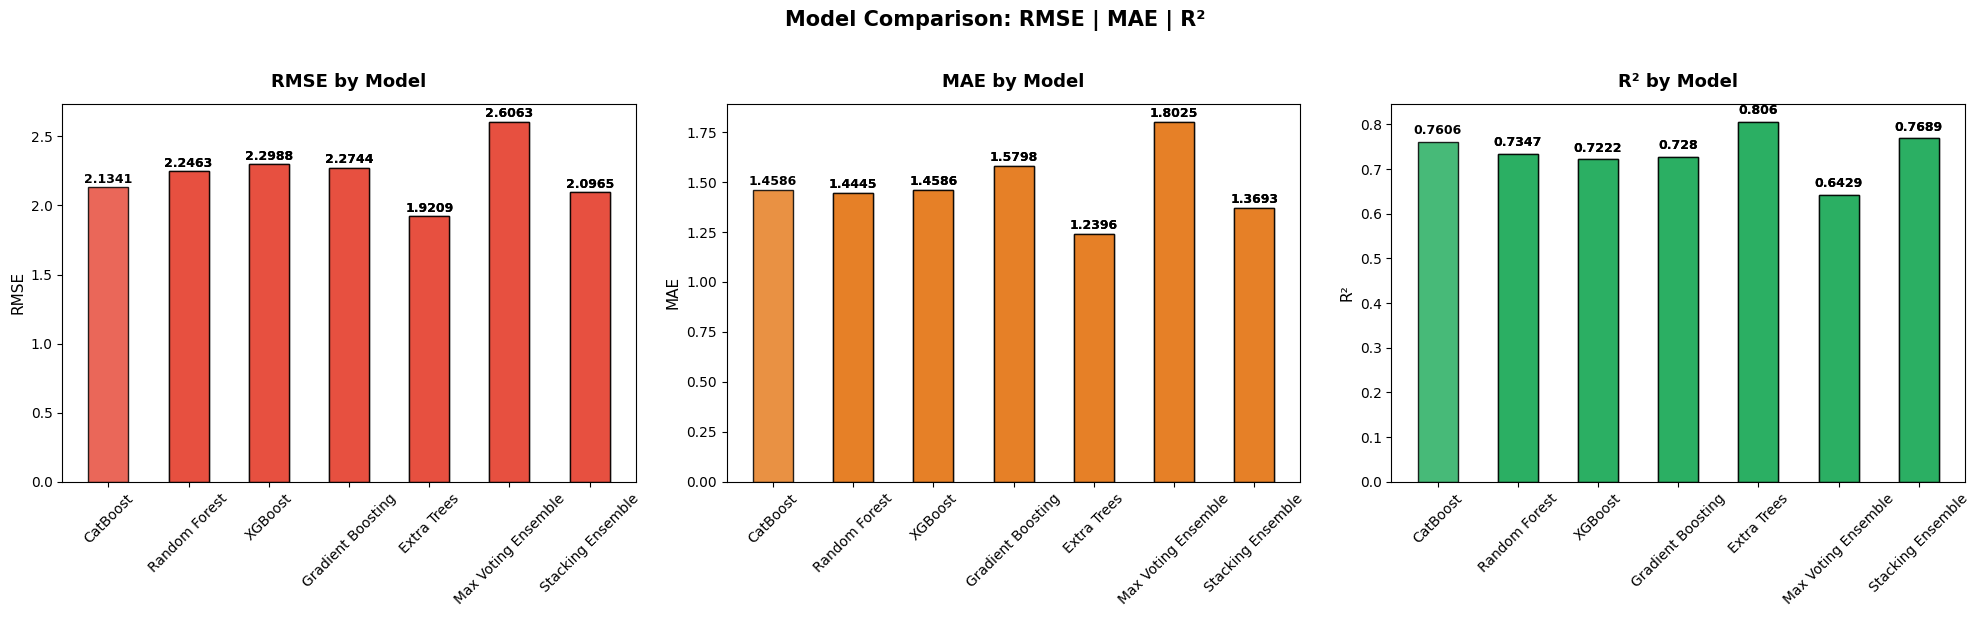

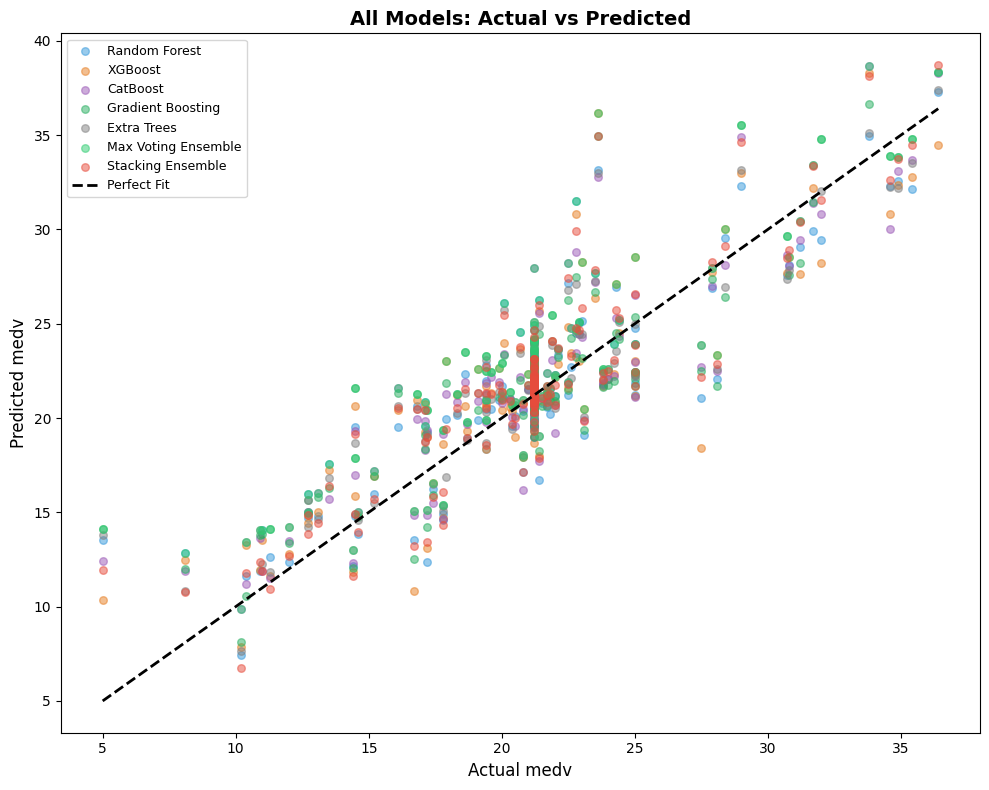


Done! All steps completed successfully.


In [ ]:
# ============================================================
# FINAL COMPARISON TABLE
# ============================================================
print("\n" + "=" * 60)
print("FINAL MODEL COMPARISON")
print("=" * 60)

results_df = pd.DataFrame(results).set_index("Model")
print("\n", results_df.to_string())

# Bar chart comparison — all 3 metrics side by side, landscape
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
metrics = ["RMSE", "MAE", "R²"]
colors_list = ['#e74c3c', '#e67e22', '#27ae60']

for ax, metric, color in zip(axes, metrics, colors_list):
    bars = ax.bar(results_df.index, results_df[metric], color=color, edgecolor='black', alpha=0.85, width=0.5)
    ax.set_title(f"{metric} by Model", fontsize=13, fontweight='bold', pad=12)
    ax.set_ylabel(metric, fontsize=11)
    ax.tick_params(axis='x', rotation=45, labelsize=10)
    ax.tick_params(axis='y', labelsize=10)
    for bar, v in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                str(v), ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle("Model Comparison: RMSE | MAE | R²", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

# Actual vs Predicted — all models in one combined chart
preds = {
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb,
    "CatBoost": y_pred_cat,
    "Gradient Boosting": y_pred_gbr,
    "Extra Trees": y_pred_et,
    "Max Voting Ensemble": y_pred_maxvote,
    "Stacking Ensemble": y_pred_stack,
}
palette = ['#3498db', '#e67e22', '#9b59b6', '#27ae60', '#808080', '#2ecc71', '#e74c3c']

plt.figure(figsize=(10, 8))
for (name, pred), color in zip(preds.items(), palette):
    plt.scatter(y_test, pred, alpha=0.5, label=name, color=color, s=30)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Perfect Fit')
plt.xlabel("Actual medv", fontsize=12)
plt.ylabel("Predicted medv", fontsize=12)
plt.title("All Models: Actual vs Predicted", fontsize=14, fontweight='bold')
plt.legend(fontsize=9, loc='upper left')
plt.tight_layout()
plt.savefig("actual_vs_predicted.png", dpi=150)
plt.show()

print("\nDone! All steps completed successfully.")